In [16]:
import pandas as pd
import numpy as np
import joblib
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import yaml
import os
import logging
from contextlib import nullcontext
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger()

mlflow_tracking_uri = 'http://localhost:5000'  # Optional: e.g., 'http://localhost:5555'

In [14]:
# Load dataset
data_path = '../data/processed/featured_house_data.csv'  # Update path if needed
data = pd.read_csv(data_path)
X = data.drop('price', axis=1)
y = data['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
len(X_train)

61

In [12]:
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor

# Use XGBoost for RFE to stay consistent
xgb_model = XGBRegressor(objective='reg:squarederror')
xgb_model.fit(X_train, y_train)

# RFE
rfe_selector = RFE(estimator=xgb_model, n_features_to_select=10)
rfe_selector.fit(X_train, y_train)
rfe_selected_features = X.columns[rfe_selector.support_]
rfe_ignored_features = X.columns[~rfe_selector.support_]

print("✅ Top 10 Selected Features by RFE:")
for feature in rfe_selected_features:
    print(f" - {feature}")

print("\n❌ Features Ignored by RFE:")
for feature in rfe_ignored_features:
    print(f" - {feature}")

# Store for config
selected_features_dict = {
    'rfe': list(rfe_selected_features)
}

# Filter datasets to use only selected features for experimentation
X_train = X_train[rfe_selected_features]
X_test = X_test[rfe_selected_features]


✅ Top 10 Selected Features by RFE:
 - 0
 - 2
 - 3
 - 4
 - 5
 - 9
 - 12
 - 13
 - 14
 - 15

❌ Features Ignored by RFE:
 - 1
 - 6
 - 7
 - 8
 - 10
 - 11


In [17]:
# Optional MLflow setup
if mlflow_tracking_uri:
    mlflow.set_tracking_uri(mlflow_tracking_uri)
    mlflow.set_experiment("House Price Prediction Experiment")


2026/04/03 21:50:05 INFO mlflow.tracking.fluent: Experiment with name 'House Price Prediction Experiment' does not exist. Creating a new experiment.


In [18]:
# Define models and hyperparameter grids
models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(),
    'GradientBoosting': GradientBoostingRegressor(),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror')
}

model_grids = {
    'LinearRegression': {},
    'RandomForest': {
        'n_estimators': [100, 150],
        'max_depth': [None, 10, 20]
    },
    'GradientBoosting': {
        'n_estimators': [100, 250],
        'learning_rate': [0.1, 0.05],
        'max_depth': [3, 10]
    },
    'XGBoost': {
        'n_estimators': [100, 150],
        'learning_rate': [0.1, 0.05],
        'max_depth': [3, 10]
    }
}


In [19]:
def evaluate_model_with_gridsearch(name, model, grid, X_train, y_train, X_test, y_test):
    if grid:
        clf = GridSearchCV(model, grid, cv=3, scoring='r2', n_jobs=-1)
        clf.fit(X_train, y_train)
        best_model = clf.best_estimator_
        best_params = clf.best_params_
    else:
        model.fit(X_train, y_train)
        best_model = model
        best_params = model.get_params()

    y_pred = best_model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return {
        'mae': mae,
        'mse': mse,
        'rmse': rmse,
        'r2': r2,
        'model': best_model,
        'params': best_params
    }

print("MLflow tracking URI:", mlflow_tracking_uri)


MLflow tracking URI: http://localhost:5000


In [20]:
results = {}

with mlflow.start_run(run_name="model_comparison") if mlflow_tracking_uri else nullcontext():
    for name, model in models.items():
        logger.info(f"Training {name}...")
        with mlflow.start_run(run_name=name, nested=True) if mlflow_tracking_uri else nullcontext():
            evaluation = evaluate_model_with_gridsearch(name, model, model_grids[name], X_train, y_train, X_test, y_test)
            results[name] = evaluation

            if mlflow_tracking_uri:
                mlflow.log_params(evaluation['params'])
                mlflow.log_metrics({
                    'mae': evaluation['mae'],
                    'mse': evaluation['mse'],
                    'rmse': evaluation['rmse'],
                    'r2': evaluation['r2']
                })
                mlflow.sklearn.log_model(evaluation['model'], artifact_path=name.lower().replace(" ", "_"))
            
            print(f"{name} R2: {evaluation['r2']:.4f}, RMSE: {evaluation['rmse']:.2f}")


2026/04/03 22:02:36 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

INFO:root:Training LinearRegression...
2026/04/03 22:02:39 WARNING mlflow.models.model: `artifact_path` 

LinearRegression R2: 0.9901, RMSE: 21429.17
🏃 View run LinearRegression at: http://localhost:5000/#/experiments/2/runs/c78c20d2f44d406abbecca9c8fb4ea54
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/04/03 22:02:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 22:03:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
INFO:root:Training GradientBoosting...


RandomForest R2: 0.9976, RMSE: 10625.43
🏃 View run RandomForest at: http://localhost:5000/#/experiments/2/runs/e6a5232db8bc4fd0959610a8ea0f4a1b
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/04/03 22:03:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 22:03:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
INFO:root:Training XGBoost...


GradientBoosting R2: 0.9954, RMSE: 14639.92
🏃 View run GradientBoosting at: http://localhost:5000/#/experiments/2/runs/376cf42ac7ac4900b5841ca2da122bfe
🧪 View experiment at: http://localhost:5000/#/experiments/2


2026/04/03 22:03:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 22:03:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost R2: 0.9737, RMSE: 34984.50
🏃 View run XGBoost at: http://localhost:5000/#/experiments/2/runs/553e14f89ed040fda59baac02af7b6b7
🧪 View experiment at: http://localhost:5000/#/experiments/2
🏃 View run model_comparison at: http://localhost:5000/#/experiments/2/runs/28620ab47b3d40968a026641ab61f9ff
🧪 View experiment at: http://localhost:5000/#/experiments/2


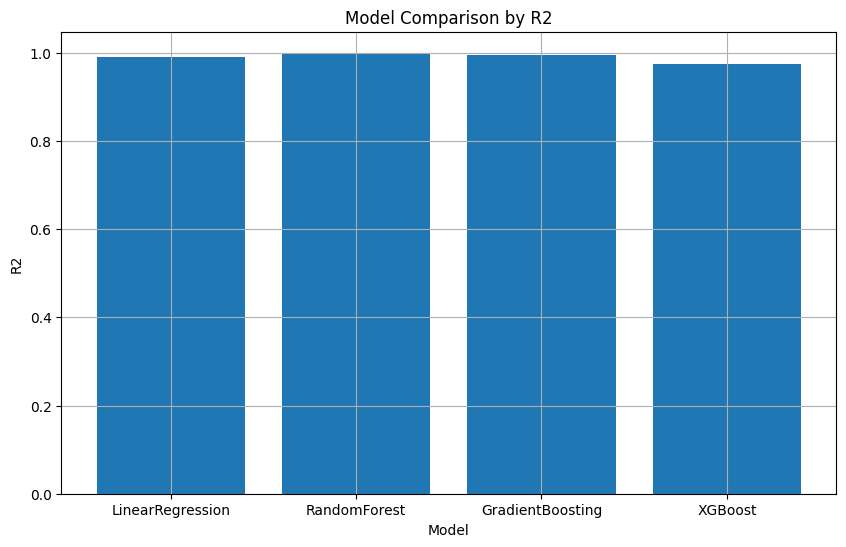

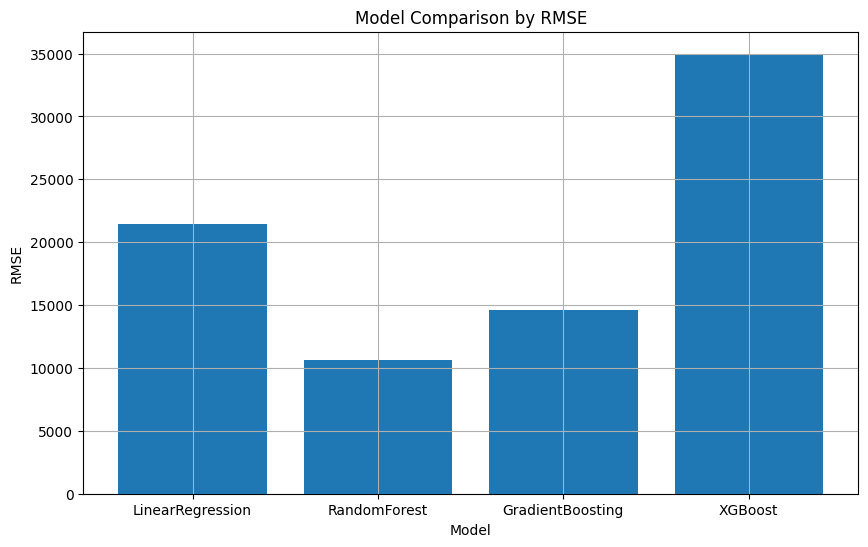

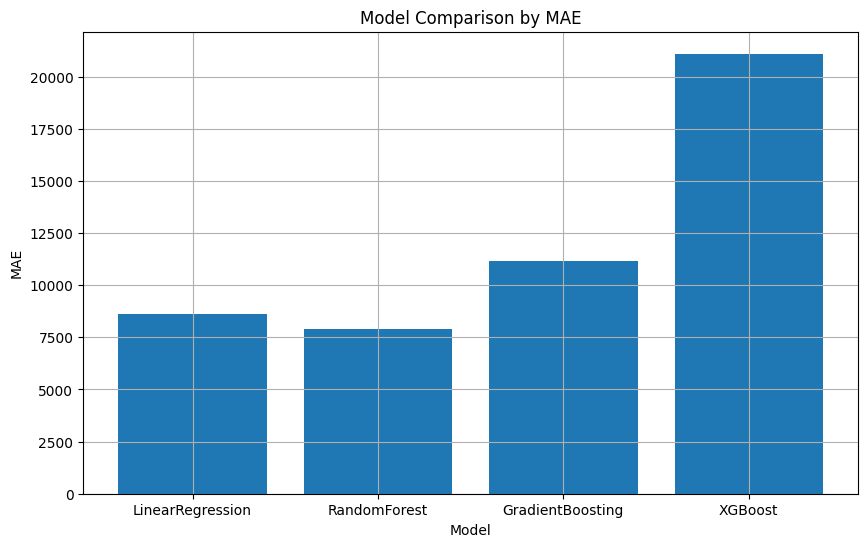

In [21]:
def plot_model_metrics(results, metric='r2'):
    names = list(results.keys())
    values = [results[name][metric] for name in names]

    plt.figure(figsize=(10, 6))
    plt.bar(names, values)
    plt.title(f'Model Comparison by {metric.upper()}')
    plt.xlabel('Model')
    plt.ylabel(metric.upper())
    plt.grid(True)
    plt.show()

# Example usage:
plot_model_metrics(results, metric='r2')
plot_model_metrics(results, metric='rmse')
plot_model_metrics(results, metric='mae')



In [25]:
results

{'LinearRegression': {'mae': 8609.57631041496,
  'mse': 459209433.8925693,
  'rmse': np.float64(21429.172496682397),
  'r2': 0.9901413701294145,
  'model': LinearRegression(),
  'params': {'copy_X': True,
   'fit_intercept': True,
   'n_jobs': None,
   'positive': False,
   'tol': 1e-06}},
 'RandomForest': {'mae': 7885.0,
  'mse': 112899712.5,
  'rmse': np.float64(10625.427638452958),
  'r2': 0.9975761898691885,
  'model': RandomForestRegressor(),
  'params': {'max_depth': None, 'n_estimators': 100}},
 'GradientBoosting': {'mae': 11178.600762582599,
  'mse': 214327239.40445346,
  'rmse': np.float64(14639.91937834541),
  'r2': 0.9953986726566963,
  'model': GradientBoostingRegressor(n_estimators=250),
  'params': {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 250}},
 'XGBoost': {'mae': 21103.158203125,
  'mse': 1223915520.0,
  'rmse': np.float64(34984.503998198976),
  'r2': 0.9737241268157959,
  'model': XGBRegressor(base_score=None, booster=None, callbacks=None,
               

In [22]:
import yaml

# Save model config with selected features 
# Display information about the best model
best_model_name = max(results, key=lambda x: results[x]['r2'])
best_model = results[best_model_name]['model']
best_params = best_model.get_params()
best_r2 = float(results[best_model_name]['r2'])
best_mae = float(results[best_model_name]['mae'])
best_rmse = float(results[best_model_name]['rmse'])

print(f"🏆 Best Model: {best_model_name}")
print(f"   R² Score: {best_r2:.4f}")
print(f"   MAE: {best_mae:.2f}")
print(f"   RMSE: {best_rmse:.2f}")

model_config = {
    'model': {
        'name': 'house_price_model',
        'best_model': best_model_name,
        'parameters': best_params,
        'r2_score': best_r2,
        'mae': best_mae,
        'target_variable': 'price',
        'feature_sets': selected_features_dict
    }
}

config_path = '../configs/model_config.yaml'
os.makedirs(os.path.dirname(config_path), exist_ok=True)
with open(config_path, 'w') as f:
    yaml.dump(model_config, f)

print(f"Saved model config to {config_path}")


🏆 Best Model: RandomForest
   R² Score: 0.9976
   MAE: 7885.00
   RMSE: 10625.43
Saved model config to ../configs/model_config.yaml
